# LLM Sequential Workflow

In [8]:
# libraries
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langchain_groq.chat_models import ChatGroq
from IPython.display import Image
from typing import TypedDict
from dotenv import load_dotenv
import os

In [4]:
# load api key
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [5]:
# load LLM model
llmModel = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature = 0,
    max_tokens = None
)

In [6]:
# define state
class LLMstate(TypedDict):
    question: str
    answer: str

In [7]:
# define llmQA function
def llmQA(state: LLMstate) -> LLMstate:
    question = state["question"]
    prompt = f"Answer the following question: {question}"

    answer = llmModel.invoke(prompt).content
    state["answer"] = answer
    return state

In [15]:
# define graph
graph = StateGraph(LLMstate)

# define node
graph.add_node("llm_qa", llmQA)

# define edge
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

# compile
workflow = graph.compile()

In [16]:
# execute graph
initial_state = {
    "question": "What is the square root of 49."
}
final_state = workflow.invoke(initial_state)
final_state

{'question': 'What is the square root of 49.',
 'answer': 'The square root of 49 is 7.'}

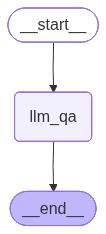

In [17]:
# check graph
Image(workflow.get_graph().draw_mermaid_png())